In [1]:
pip install segmentation-models-pytorch albumentations opencv-python


Note: you may need to restart the kernel to use updated packages.


In [6]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2
import albumentations as A
import segmentation_models_pytorch as smp
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter


In [7]:
class KvasirDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.image_filenames = sorted(os.listdir(image_dir))
        self.mask_filenames = sorted(os.listdir(mask_dir))
        self.transform = transform

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.image_filenames[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_filenames[idx])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]
        mask = (mask > 0).float().unsqueeze(0)
        return image, mask


In [8]:
transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(),
    ToTensorV2(),
])


In [9]:
IMAGE_DIR = "C:/Medical_image_analysis/colon_cancer/kvasir-seg/Kvasir-SEG/images"
MASK_DIR = "C:/Medical_image_analysis/colon_cancer/kvasir-seg/Kvasir-SEG/masks"

dataset = KvasirDataset(IMAGE_DIR, MASK_DIR, transform=transform)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = smp.UnetPlusPlus(encoder_name="resnet34", in_channels=3, classes=1, activation=None).to(device)
loss_fn = smp.losses.DiceLoss(mode='binary')
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [12]:
writer = SummaryWriter("runs/unetplusplus_kvasir")
num_epochs = 25
best_dice = 0

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    writer.add_scalar("Loss/train", epoch_loss / len(train_loader), epoch)

    # --- Validation
    model.eval()
    iou_scores, dice_scores = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            preds = preds.view(-1)
            masks = masks.view(-1)

            intersection = (preds.bool() & masks.bool()).float().sum()
            union = (preds.bool() | masks.bool()).float().sum()
            dice = (2. * intersection) / (preds.sum() + masks.sum() + 1e-7)
            iou = intersection / (union + 1e-7)

            iou_scores.append(iou.item())
            dice_scores.append(dice.item())

    mean_iou = np.mean(iou_scores)
    mean_dice = np.mean(dice_scores)
    writer.add_scalar("IoU/val", mean_iou, epoch)
    writer.add_scalar("Dice/val", mean_dice, epoch)

    print(f"✅ Val IoU: {mean_iou:.4f}, Dice Score: {mean_dice:.4f}")

    # Save best model
    if mean_dice > best_dice:
        best_dice = mean_dice
        torch.save(model.state_dict(), "best_unetplusplus_model.pth")
        print("💾 Best model saved.")


Epoch 1/25: 100%|██████████| 100/100 [00:12<00:00,  7.77it/s]


✅ Val IoU: 0.6776, Dice Score: 0.8046
💾 Best model saved.


Epoch 2/25: 100%|██████████| 100/100 [00:12<00:00,  8.08it/s]


✅ Val IoU: 0.6879, Dice Score: 0.8118
💾 Best model saved.


Epoch 3/25: 100%|██████████| 100/100 [00:12<00:00,  7.99it/s]


...

✅ Val IoU: 0.7611, Dice Score: 0.8578


Epoch 24/25: 100%|██████████| 100/100 [00:12<00:00,  7.86it/s]


✅ Val IoU: 0.7851, Dice Score: 0.8753


Epoch 25/25: 100%|██████████| 100/100 [00:12<00:00,  7.87it/s]


✅ Val IoU: 0.7804, Dice Score: 0.8709


In [16]:
def evaluate_with_tta(model, dataloader):
    model.eval()
    tta_transforms = [lambda x: x, lambda x: torch.flip(x, dims=[3])]
    iou_scores, dice_scores = [], []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="🔍 Evaluating with TTA"):
            images, masks = images.to(device), masks.to(device)
            preds_total = 0
            for tta in tta_transforms:
                augmented_images = tta(images)
                preds = torch.sigmoid(model(augmented_images))
                preds = tta(preds)
                preds_total += preds
            preds_total /= len(tta_transforms)
            preds = preds_total > 0.5

            preds = preds.view(-1)
            masks = masks.view(-1)

            intersection = (preds & masks).float().sum()
            union = (preds | masks).float().sum()
            dice = (2. * intersection) / (preds.sum() + masks.sum() + 1e-7)
            iou = intersection / (union + 1e-7)

            iou_scores.append(iou.item())
            dice_scores.append(dice.item())

print(f"🎯 TTA Test IoU: {np.mean(iou_scores):.4f}")
print(f"🎯 TTA Test Dice Score: {np.mean(dice_scores):.4f}")


🎯 TTA Test IoU: 0.7804
🎯 TTA Test Dice Score: 0.8709


In [14]:
def visualize_predictions(model, dataloader, device, num_samples=5):
    model.eval()
    with torch.no_grad():
        for idx, (images, masks) in enumerate(dataloader):
            if idx >= num_samples:
                break
            images, masks = images.to(device), masks.to(device)
            outputs = torch.sigmoid(model(images)) > 0.5

            image = images[0].cpu().permute(1, 2, 0).numpy()
            gt = masks[0].cpu().squeeze().numpy()
            pred = outputs[0].cpu().squeeze().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(image)
            plt.title("Image")
            plt.subplot(1, 3, 2)
            plt.imshow(gt, cmap='gray')
            plt.title("Ground Truth")
            plt.subplot(1, 3, 3)
            plt.imshow(pred, cmap='gray')
            plt.title("Prediction")
            plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285712].


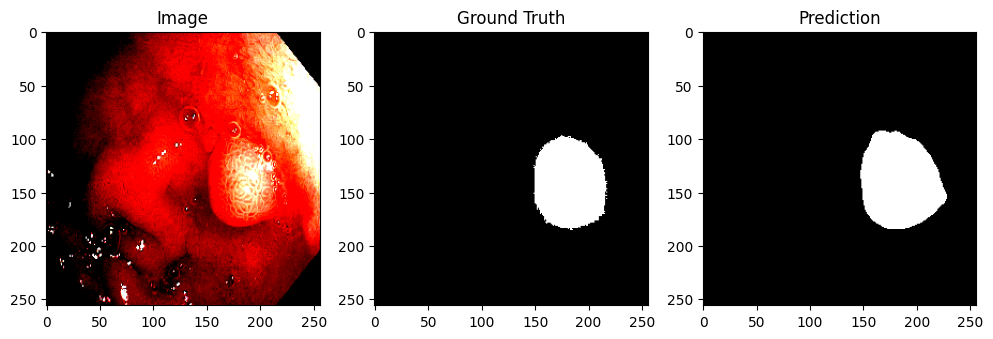

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


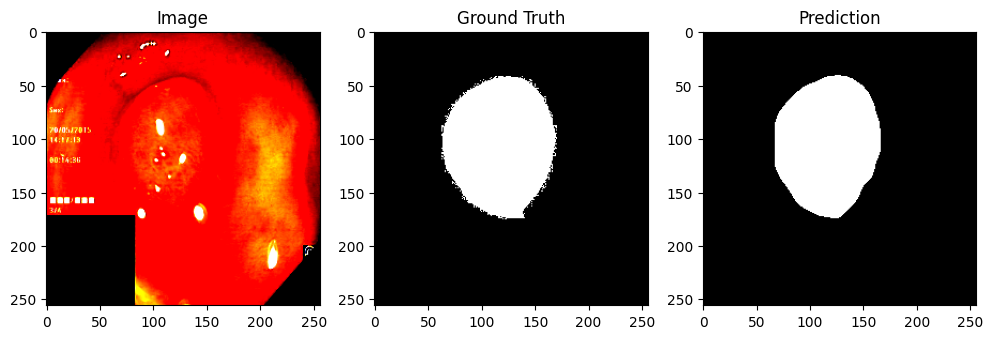

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5354247].


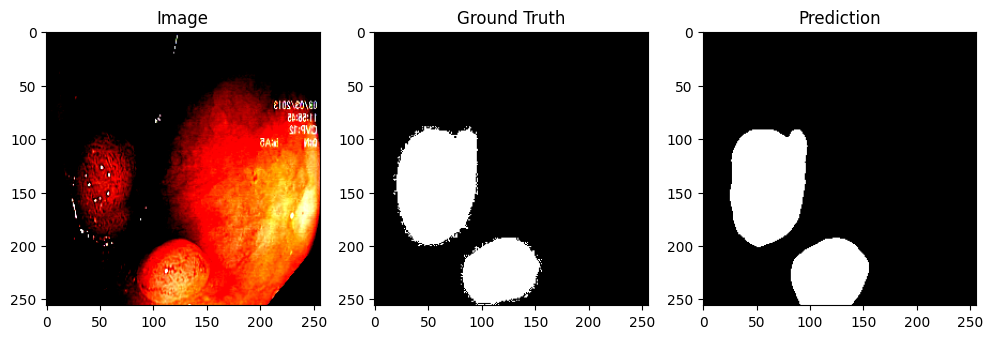

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5702832].


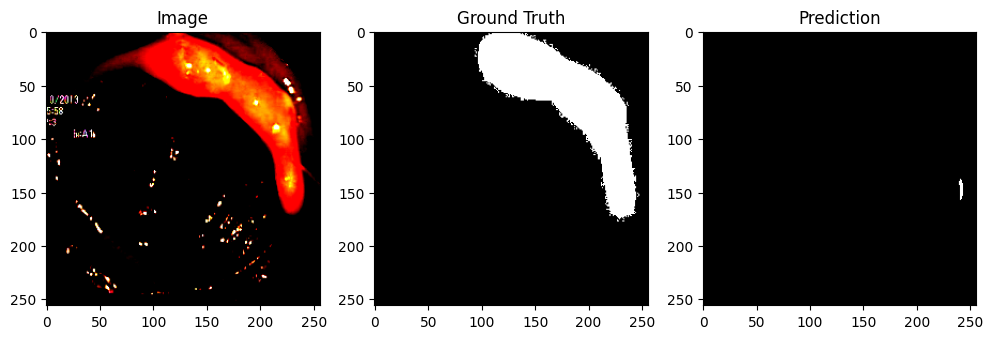

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.6399999].


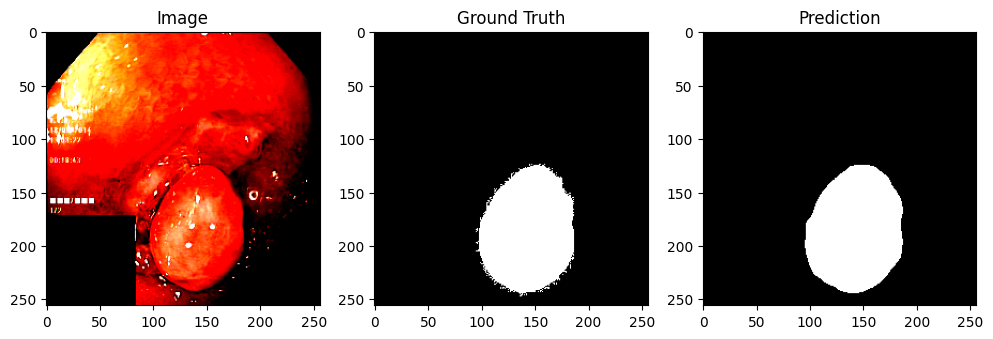

In [15]:
# Call the visualization function
visualize_predictions(model, val_loader, device, 5)

In [ ]:
#hyper parameter tuning

In [19]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, random_split
from torch import nn, optim
import segmentation_models_pytorch as smp
from sklearn.model_selection import train_test_split
from albumentations.pytorch import ToTensorV2
import albumentations as A
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

# Paths
IMAGE_DIR = "C:/Medical_image_analysis/colon_cancer/kvasir-seg/Kvasir-SEG/images"
MASK_DIR = "C:/Medical_image_analysis/colon_cancer/kvasir-seg/Kvasir-SEG/masks"
writer = SummaryWriter("runs/unetpp_experiment")

import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset
import torch

class KvasirDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = (mask > 0).float()
        return image, mask.unsqueeze(0)



# Transforms
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(),
    A.RandomBrightnessContrast(),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.Normalize(),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2(),
])

# Load dataset
full_dataset = KvasirDataset(IMAGE_DIR, MASK_DIR, transform=train_transform)
val_size = int(0.2 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Apply val transform to val dataset
val_dataset.dataset.transform = val_transform

# Dataloaders
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Model
model = smp.UnetPlusPlus(encoder_name='resnet34', encoder_weights='imagenet', in_channels=3, classes=1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss, Optimizer, Scheduler
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3, verbose=True)

# Training Function
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    epoch_loss = 0
    for images, masks in tqdm(dataloader, desc="Training"):
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

# Evaluation
def evaluate_model(model, dataloader):
    model.eval()
    dice_scores, iou_scores = [], []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = torch.sigmoid(model(images))
            preds = (outputs > 0.5).float()

            preds = preds.view(-1)
            masks = masks.view(-1)

            intersection = (preds.bool() & masks.bool()).float().sum()
            union = (preds.bool() | masks.bool()).float().sum()
            dice = (2. * intersection) / (preds.sum() + masks.sum() + 1e-7)
            iou = intersection / (union + 1e-7)

            dice_scores.append(dice.item())
            iou_scores.append(iou.item())
    return np.mean(iou_scores), np.mean(dice_scores)

# Training Loop
num_epochs = 50
best_dice = 0
early_stop_patience = 7
early_stop_counter = 0

for epoch in range(num_epochs):
    print(f"\n🌟 Epoch {epoch+1}/{num_epochs}")
    epoch_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_iou, val_dice = evaluate_model(model, val_loader)

    writer.add_scalar("Loss/train", epoch_loss, epoch)
    writer.add_scalar("IoU/val", val_iou, epoch)
    writer.add_scalar("Dice/val", val_dice, epoch)

    scheduler.step(val_dice)

    print(f"🔁 Train Loss: {epoch_loss:.4f}")
    print(f"✅ Val IoU: {val_iou:.4f}, Dice Score: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_unetpp.pth")
        early_stop_counter = 0
        print("💾 Saved best model.")
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print("⏹️ Early stopping triggered.")
            break

# TTA Evaluation (Simple Horizontal Flip)
def tta_inference(model, dataloader):
    model.eval()
    dice_scores, iou_scores = [], []
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="TTA Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs1 = torch.sigmoid(model(images))
            outputs2 = torch.sigmoid(model(torch.flip(images, dims=[3])))
            outputs2 = torch.flip(outputs2, dims=[3])

            outputs = (outputs1 + outputs2) / 2
            preds = (outputs > 0.5).float()

            preds = preds.view(-1)
            masks = masks.view(-1)

            intersection = (preds.bool() & masks.bool()).float().sum()
            union = (preds.bool() | masks.bool()).float().sum()
            dice = (2. * intersection) / (preds.sum() + masks.sum() + 1e-7)
            iou = intersection / (union + 1e-7)

            dice_scores.append(dice.item())
            iou_scores.append(iou.item())

    print(f"\n🎯 TTA Test IoU: {np.mean(iou_scores):.4f}")
    print(f"🎯 TTA Test Dice Score: {np.mean(dice_scores):.4f}")

# Load best model and run TTA
model.load_state_dict(torch.load("best_unetpp.pth"))
tta_inference(model, val_loader)



🌟 Epoch 1/50


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 11.91it/s]


🔁 Train Loss: 0.2891
✅ Val IoU: 0.5702, Dice Score: 0.7206
💾 Saved best model.

🌟 Epoch 2/50


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 12.05it/s]


🔁 Train Loss: 0.1977
✅ Val IoU: 0.5690, Dice Score: 0.7204

🌟 Epoch 3/50


...

🔁 Train Loss: 0.0205
✅ Val IoU: 0.7166, Dice Score: 0.8270

🌟 Epoch 29/50


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 11.93it/s]


🔁 Train Loss: 0.0199
✅ Val IoU: 0.7167, Dice Score: 0.8274
⏹️ Early stopping triggered.


TTA Evaluating: 100%|██████████| 25/25 [00:02<00:00,  9.20it/s]


🎯 TTA Test IoU: 0.7076
🎯 TTA Test Dice Score: 0.8210


In [21]:
#tru with efficient net b4

import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from sklearn.model_selection import train_test_split
from PIL import Image
import segmentation_models_pytorch as smp
from albumentations.pytorch import ToTensorV2
import albumentations as A
from tqdm import tqdm
import cv2

# Set paths
IMAGE_DIR = r"C:\Medical_image_analysis\colon_cancer\kvasir-seg\Kvasir-SEG\images"
MASK_DIR = r"C:\Medical_image_analysis\colon_cancer\kvasir-seg\Kvasir-SEG\masks"

# Constants
IMG_SIZE = 256
BATCH_SIZE = 8
LR = 1e-4
NUM_EPOCHS = 50
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dataset class
class KvasirDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        mask = (mask > 0).float().unsqueeze(0)
        return image, mask

transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.RandomRotate90(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.ElasticTransform(p=0.2, alpha=1, sigma=50, alpha_affine=50),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(),
    ToTensorV2()
])


# Load data
image_paths = sorted([os.path.join(IMAGE_DIR, x) for x in os.listdir(IMAGE_DIR)])
mask_paths = sorted([os.path.join(MASK_DIR, x) for x in os.listdir(MASK_DIR)])
train_imgs, val_imgs, train_masks, val_masks = train_test_split(image_paths, mask_paths, test_size=0.2, random_state=42)

train_dataset = KvasirDataset(train_imgs, train_masks, transform=transform)
val_dataset = KvasirDataset(val_imgs, val_masks, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Custom loss function
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=0.75):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)
        TP = (inputs * targets).sum()
        FP = ((1 - targets) * inputs).sum()
        FN = (targets * (1 - inputs)).sum()
        tversky = (TP + 1e-7) / (TP + self.alpha*FP + self.beta*FN + 1e-7)
        return (1 - tversky) ** self.gamma

# Model setup
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(DEVICE)

optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = FocalTverskyLoss()

# Evaluation metrics
def calculate_metrics(preds, masks):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float()
    intersection = (preds * masks).sum()
    union = ((preds + masks) > 0).float().sum()
    dice = (2 * intersection) / (preds.sum() + masks.sum() + 1e-7)
    iou = intersection / (union + 1e-7)
    return iou.item(), dice.item()

# Training loop
def train_model():
    best_dice = 0.0
    for epoch in range(NUM_EPOCHS):
        model.train()
        train_loss = 0
        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        total_iou, total_dice = 0, 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(DEVICE), masks.to(DEVICE)
                outputs = model(images)
                iou, dice = calculate_metrics(outputs, masks)
                total_iou += iou
                total_dice += dice

        avg_iou = total_iou / len(val_loader)
        avg_dice = total_dice / len(val_loader)
        print(f"\n📊 Val IoU: {avg_iou:.4f} | Val Dice: {avg_dice:.4f} | Train Loss: {train_loss / len(train_loader):.4f}")

        # Save best model
        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(), "best_model.pth")
            print("✅ Model saved!")

train_model()


C:\Users\Admin\AppData\Local\Temp\ipykernel_9776\913071927.py:55: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.2, alpha=1, sigma=50, alpha_affine=50),
Epoch 1/50: 100%|██████████| 100/100 [00:31<00:00,  3.22it/s]



📊 Val IoU: 0.5998 | Val Dice: 0.7431 | Train Loss: 0.7254
✅ Model saved!


Epoch 2/50: 100%|██████████| 100/100 [00:20<00:00,  4.78it/s]



📊 Val IoU: 0.7013 | Val Dice: 0.8210 | Train Loss: 0.5538
✅ Model saved!


Epoch 3/50: 100%|██████████| 100/100 [00:20<00:00,  4.81it/s]


...


📊 Val IoU: 0.7886 | Val Dice: 0.8787 | Train Loss: 0.1274


Epoch 49/50: 100%|██████████| 100/100 [00:21<00:00,  4.74it/s]



📊 Val IoU: 0.7804 | Val Dice: 0.8737 | Train Loss: 0.1318


Epoch 50/50: 100%|██████████| 100/100 [00:20<00:00,  4.78it/s]



📊 Val IoU: 0.7841 | Val Dice: 0.8761 | Train Loss: 0.1354
